In [1]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import defaultdict

# Path to dataset
DATA_DIR = pathlib.Path("../data/mvtec")

# Get all categories
categories = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Total categories: {len(categories)}")
print(f"Categories: {categories}")

Total categories: 15
Categories: ['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']


In [2]:
# Count images per category
print(f"{'Category':<15} {'Train(normal)':<15} {'Test(normal)':<15} {'Test(defect)':<15}")
print("-" * 60)

for cat in categories:
    cat_path = DATA_DIR / cat
    
    # Count train normal images
    train_normal = len(list((cat_path / 'train' / 'good').glob('*.png')))
    
    # Count test normal images
    test_normal = len(list((cat_path / 'test' / 'good').glob('*.png')))
    
    # Count test defect images (all subfolders except 'good')
    test_defect = 0
    for defect_dir in (cat_path / 'test').iterdir():
        if defect_dir.name != 'good':
            test_defect += len(list(defect_dir.glob('*.png')))
    
    print(f"{cat:<15} {train_normal:<15} {test_normal:<15} {test_defect:<15}")

Category        Train(normal)   Test(normal)    Test(defect)   
------------------------------------------------------------
bottle          209             20              63             
cable           224             58              92             
capsule         219             23              109            
carpet          280             28              89             
grid            264             21              57             
hazelnut        391             40              70             
leather         245             32              92             
metal_nut       220             22              93             
pill            267             26              141            
screw           320             41              119            
tile            230             33              84             
toothbrush      60              12              30             
transistor      213             60              40             
wood            247             19         

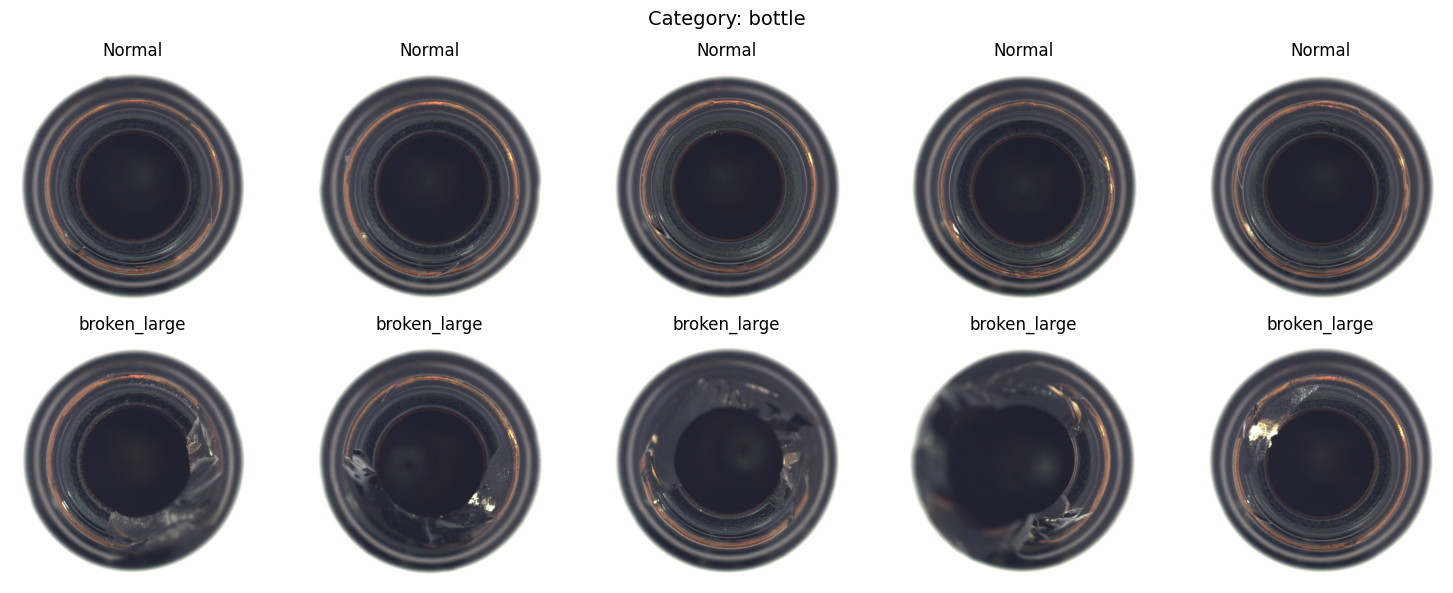

Saved to outputs/sample_images.png


In [3]:
# Visualize sample images from each split for one category
category = 'bottle'
cat_path = DATA_DIR / category

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Category: {category}', fontsize=14)

# Top row — normal images
normal_imgs = list((cat_path / 'train' / 'good').glob('*.png'))[:5]
for i, img_path in enumerate(normal_imgs):
    img = mpimg.imread(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title('Normal')
    axes[0, i].axis('off')

# Bottom row — defect images
defect_dirs = [d for d in (cat_path / 'test').iterdir() if d.name != 'good']
defect_imgs = []
for d in defect_dirs:
    defect_imgs.extend(list(d.glob('*.png')))
    
for i, img_path in enumerate(defect_imgs[:5]):
    img = mpimg.imread(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title(img_path.parent.name)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('../outputs/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/sample_images.png")

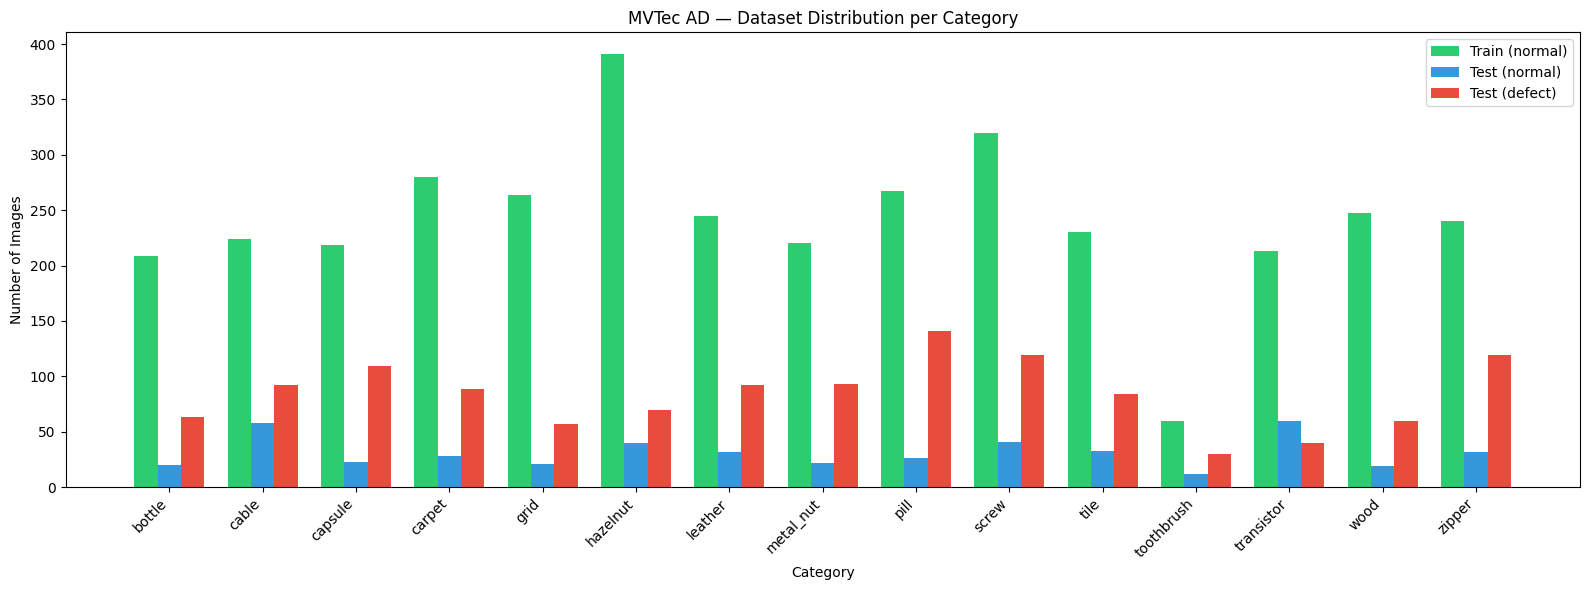

Saved to outputs/dataset_distribution.png


In [4]:
# Plot dataset distribution
categories_list = categories
train_counts = []
test_normal_counts = []
test_defect_counts = []

for cat in categories_list:
    cat_path = DATA_DIR / cat
    train_counts.append(len(list((cat_path / 'train' / 'good').glob('*.png'))))
    test_normal_counts.append(len(list((cat_path / 'test' / 'good').glob('*.png'))))
    test_defect = sum(len(list(d.glob('*.png'))) 
                     for d in (cat_path / 'test').iterdir() 
                     if d.name != 'good')
    test_defect_counts.append(test_defect)

x = np.arange(len(categories_list))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, train_counts, width, label='Train (normal)', color='#2ecc71')
ax.bar(x, test_normal_counts, width, label='Test (normal)', color='#3498db')
ax.bar(x + width, test_defect_counts, width, label='Test (defect)', color='#e74c3c')

ax.set_xlabel('Category')
ax.set_ylabel('Number of Images')
ax.set_title('MVTec AD — Dataset Distribution per Category')
ax.set_xticks(x)
ax.set_xticklabels(categories_list, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/dataset_distribution.png")

In [5]:
import sys
sys.path.append('../src')

from dataset import MVTecDataset, get_transforms

# Test the dataset
train_dataset = MVTecDataset(
    root_dir='../data/mvtec',
    category='bottle',
    split='train',
    transform=get_transforms('train')
)

test_dataset = MVTecDataset(
    root_dir='../data/mvtec',
    category='bottle',
    split='test',
    transform=get_transforms('test')
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Check one sample
img, label, path = train_dataset[0]
print(f"\nImage shape: {img.shape}")
print(f"Label: {label} (0=normal, 1=defect)")
print(f"Path: {path}")

Train samples: 209
Test samples: 83

Image shape: torch.Size([3, 224, 224])
Label: 0 (0=normal, 1=defect)
Path: ..\data\mvtec\bottle\train\good\000.png


In [6]:
from model import get_model
import torch

model = get_model('resnet50')
x = torch.randn(4, 3, 224, 224)
out = model(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {out.shape}")
print("Model working!")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\sharm/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:04<00:00, 24.7MB/s]


Input shape: torch.Size([4, 3, 224, 224])
Output shape: torch.Size([4, 2])
Model working!


In [1]:
import sys
sys.path.append('../src')

from dataset import MVTecDataset, get_transforms
from model import get_model
from train import train
from torch.utils.data import DataLoader
import torch

# Setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Datasets
train_dataset = MVTecDataset('../data/mvtec', 'bottle', 'train', get_transforms('train'))
test_dataset = MVTecDataset('../data/mvtec', 'bottle', 'test', get_transforms('test'))

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

# Model
model = get_model('resnet50').to(device)

# Train
history = train(model, train_loader, test_loader, 
                num_epochs=5, lr=0.001, device=device)

Using device: cuda
Training on cuda
Epoch    Train Loss   Train Acc    Test Loss    Test Acc    
--------------------------------------------------------


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  3.14it/s]


1        0.0907       92.34        14.4526      24.10        (9.1s)


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  4.22it/s]


2        0.0000       100.00       12.4704      24.10        (6.4s)


...

3        0.0000       100.00       11.1686      24.10        (6.4s)


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  4.30it/s]


4        0.0000       100.00       10.7523      24.10        (6.2s)


Evaluating: 100%|██████████| 6/6 [00:01<00:00,  4.23it/s]

5        0.0000       100.00       10.4731      24.10        (6.3s)

Best Test Accuracy: 24.10%
Model saved to ..\outputs/best_model.pth


In [2]:
# Check class distribution in test set
normal_count = sum(1 for _, label, _ in test_dataset if label == 0)
defect_count = sum(1 for _, label, _ in test_dataset if label == 1)
print(f"Test - Normal: {normal_count}, Defect: {defect_count}")

# Fix with class weights
import torch
total = normal_count + defect_count
weight_normal = total / (2 * normal_count)
weight_defect = total / (2 * defect_count)
class_weights = torch.tensor([weight_normal, weight_defect]).to(device)
print(f"Class weights: Normal={weight_normal:.2f}, Defect={weight_defect:.2f}")

Test - Normal: 20, Defect: 63
Class weights: Normal=2.08, Defect=0.66


In [3]:
from dataset import MVTecDataset, get_transforms
from model import get_model
from train import train
from torch.utils.data import DataLoader
import torch

# Setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Datasets
train_dataset = MVTecDataset('../data/mvtec', 'bottle', 'train', get_transforms('train'))
test_dataset = MVTecDataset('../data/mvtec', 'bottle', 'test', get_transforms('test'))

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

# Class weights to handle imbalance
class_weights = torch.tensor([2.08, 0.66]).to(device)

# Model
model = get_model('resnet50').to(device)

# Train with class weights
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Manual training loop
from tqdm import tqdm

best_acc = 0
print(f"Training on {device}")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Test Loss':<12} {'Test Acc':<12}")
print("-" * 56)

for epoch in range(10):
    # Train
    model.train()
    train_loss, correct, total = 0, 0, 0
    for imgs, labels, _ in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        correct += outputs.max(1)[1].eq(labels).sum().item()
        total += labels.size(0)
    train_acc = 100. * correct / total

    # Evaluate
    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels, _ in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            test_loss += criterion(outputs, labels).item()
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
    test_acc = 100. * correct / total
    scheduler.step()

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), '../outputs/best_model.pth')

    print(f"{epoch+1:<8} {train_loss/len(train_loader):<12.4f} {train_acc:<12.2f} "
          f"{test_loss/len(test_loader):<12.4f} {test_acc:<12.2f}")

print(f"\nBest Test Accuracy: {best_acc:.2f}%")

Training on cuda
Epoch    Train Loss   Train Acc    Test Loss    Test Acc    
--------------------------------------------------------


Epoch 1: 100%|██████████| 14/14 [00:05<00:00,  2.74it/s]


1        0.3904       77.03        1.5873       24.10       


Epoch 2: 100%|██████████| 14/14 [00:04<00:00,  2.88it/s]


2        0.0181       100.00       3.0584       24.10       


...

8        0.0021       100.00       3.8487       24.10       


Epoch 9: 100%|██████████| 14/14 [00:04<00:00,  2.91it/s]


9        0.0020       100.00       3.8470       24.10       


Epoch 10: 100%|██████████| 14/14 [00:04<00:00,  2.92it/s]


10       0.0020       100.00       3.8776       24.10       

Best Test Accuracy: 24.10%


In [4]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

# Feature extractor - use pretrained ResNet50 without the classifier
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V1')
        # Use layers up to layer3 for patch features
        self.features = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        return x.view(x.size(0), -1)

# Extract features from all training images
def extract_features(dataset, model, device, batch_size=16):
    loader = DataLoader(dataset, batch_size=batch_size, 
                       shuffle=False, num_workers=0)
    features = []
    model.eval()
    
    with torch.no_grad():
        for imgs, _, _ in tqdm(loader, desc='Extracting features'):
            imgs = imgs.to(device)
            feat = model(imgs)
            features.append(feat.cpu().numpy())
    
    return np.concatenate(features, axis=0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Only use NORMAL training images
train_dataset = MVTecDataset('../data/mvtec', 'bottle', 
                              'train', get_transforms('test'))
test_dataset = MVTecDataset('../data/mvtec', 'bottle', 
                             'test', get_transforms('test'))

extractor = FeatureExtractor().to(device)

print("Extracting training features...")
train_features = extract_features(train_dataset, extractor, device)

print("Extracting test features...")
test_features = extract_features(test_dataset, extractor, device)

print(f"Train features shape: {train_features.shape}")
print(f"Test features shape: {test_features.shape}")

Extracting training features...


Extracting features: 100%|██████████| 14/14 [00:05<00:00,  2.39it/s]


Extracting test features...


Extracting features: 100%|██████████| 6/6 [00:02<00:00,  2.68it/s]

Train features shape: (209, 2048)
Test features shape: (83, 2048)


AUROC Score: 0.9722 (97.22%)


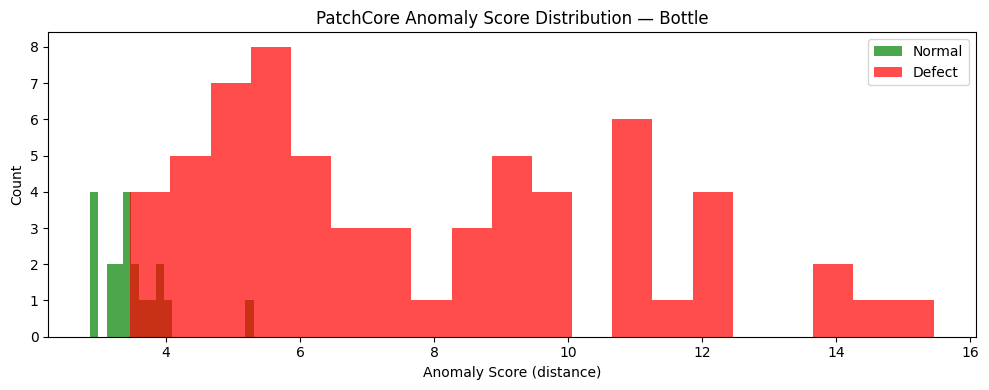

Saved to outputs/anomaly_scores.png


In [5]:
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Fit nearest neighbors on NORMAL training features
nn_model = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn_model.fit(train_features)

# For each test image find distance to nearest normal image
distances, _ = nn_model.kneighbors(test_features)
anomaly_scores = distances.squeeze()

# Get true labels
test_labels = [label for _, label, _ in test_dataset]
test_labels = np.array(test_labels)

# Calculate AUROC
auroc = roc_auc_score(test_labels, anomaly_scores)
print(f"AUROC Score: {auroc:.4f} ({auroc*100:.2f}%)")

# Plot score distribution
plt.figure(figsize=(10, 4))
plt.hist(anomaly_scores[test_labels==0], bins=20, 
         alpha=0.7, label='Normal', color='green')
plt.hist(anomaly_scores[test_labels==1], bins=20, 
         alpha=0.7, label='Defect', color='red')
plt.xlabel('Anomaly Score (distance)')
plt.ylabel('Count')
plt.title('PatchCore Anomaly Score Distribution — Bottle')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/anomaly_scores.png', dpi=150)
plt.show()
print("Saved to outputs/anomaly_scores.png")